# Denoising Autoencoders

This is based on [Geron's notebook, chapter 17](https://github.com/ageron/handson-ml3/blob/main/17_autoencoders_gans_and_diffusion_models.ipynb), in accordance with Apache License v2

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

Let's load the fashion MNIST dataset, scale it, and split it into a training set, a validation set, and a test set:

In [ ]:
# extra code – loads, scales, and splits the fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

4422102/4422102 [==============================] - 0s 0us/step


Using dropout:

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU


In [ ]:
dropout_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu")
])

In [ ]:
dropout_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(28 * 28),
    tf.keras.layers.Reshape([28, 28])
])

In [ ]:
dropout_ae = tf.keras.Sequential([dropout_encoder, dropout_decoder])

In [ ]:
dropout_ae.compile(loss="mse", optimizer="nadam")

In [ ]:
history = dropout_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 [==============================] - 15s 5ms/step - loss: 0.0284 - val_loss: 0.0212
Epoch 2/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.0219 - val_loss: 0.0195
Epoch 3/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0207 - val_loss: 0.0188
Epoch 4/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0200 - val_loss: 0.0182
Epoch 5/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0195 - val_loss: 0.0177
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0191 - val_loss: 0.0175
Epoch 7/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0189 - val_loss: 0.0172
Epoch 8/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0186 - val_loss: 0.0169
Epoch 9/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.0184 - val_loss: 0.0168
Epoch 10/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.01

In [ ]:
history = dropout_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.0302 - val_loss: 0.0237
Epoch 2/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.0238 - val_loss: 0.0217
Epoch 3/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.0225 - val_loss: 0.0208
Epoch 4/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.0217 - val_loss: 0.0200
Epoch 5/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.0211 - val_loss: 0.0196
Epoch 6/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.0206 - val_loss: 0.0192
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.0202 - val_loss: 0.0188
Epoch 8/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.0200 - val_loss: 0.0186
Epoch 9/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0197 - val_loss: 0.0184
Epoch 10/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.019

In [ ]:
def plot_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plt.imshow(reconstructions[image_index], cmap="binary")
        plt.axis("off")

1/1 [==============================] - 0s 113ms/step


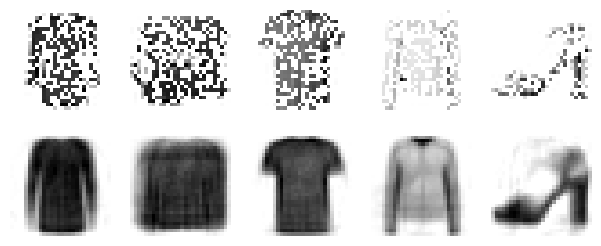

In [ ]:
tf.random.set_seed(42)
dropout = tf.keras.layers.Dropout(0.5)
plot_reconstructions(model=dropout_ae, images=dropout(X_valid, training=True))
plt.show()

If you want, you can try replacing the `Dropout` layer with `tf.keras.layers.GaussianNoise(0.2)`.